In [ ]:
#CELL 1: Install libraries and mount Google Drive
!pip install pretty_midi -q
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pretty_midi
import glob
from collections import Counter

#Paths
PROJECT_DIR = '/content/drive/MyDrive/MusicGenerationCSE425'
MIDI_OUT_DIR = f'{PROJECT_DIR}/outputs/generated_midis'
PLOTS_DIR = f'{PROJECT_DIR}/outputs/plots'
MAESTRO_DIR = f'{PROJECT_DIR}/data/raw_midi/maestro-v3.0.0'

os.makedirs(PLOTS_DIR, exist_ok=True)

print("Ready")
print(f"\nLooking for MIDI files in: {MIDI_OUT_DIR}")

#List all MIDI files found
all_files = sorted(glob.glob(f"{MIDI_OUT_DIR}/*.mid"))
print(f"\nTotal MIDI files found: {len(all_files)}")
for f in all_files:
    print(f"{os.path.basename(f)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 66.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready

Looking for MIDI files in: /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis

Total MIDI files found: 71
baseline_markov_1.mid
baseline_markov_2.mid
baseline_markov_3.mid
baseline_markov_4.mid
baseline_markov_5.mid
baseline_random_1.mid
baseline_random_2.mid
baseline_random_3.mid
baseline_random_4.mid
baseline_random_5.mid
rlhf_survey_sample_1.mid
rlhf_survey_sample_10.mid
rlhf_survey_sample_11.mid
rlhf_survey_sample_12.mid
rlhf_survey_sample_13.mid
rlhf_survey_sample_14.mid
rlhf_survey_sample_15.mid
rlhf_survey_sample_16.mid
rlhf_survey_sample_17.mid
rlhf_survey_sample_18.mid
rlhf_survey_sample_19.mid
rlhf_survey_sample_2.mid
rlhf_survey_

In [ ]:
#CELL 2: Pick a reference MIDI file from the real dataset
#Pitch Histogram Similarity comparison

import pandas as pd

df = pd.read_csv(f"{MAESTRO_DIR}/maestro-v3.0.0.csv")

#Pick 5 test files as reference (we average over multiple
test_files = df[df['split'] == 'test']['midi_filename'].head(5).tolist()
REFERENCE_FILES = [os.path.join(MAESTRO_DIR, f) for f in test_files]
print("Reference files selected from test split:")
for r in REFERENCE_FILES:
    print(f"{os.path.basename(r)}")

Reference files selected from test split:
MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AUDIO_11_R1_2009_11_R1_2009_07_WAV.midi
MIDI-Unprocessed_02_R1_2009_03-06_ORIG_MID--AUDIO_02_R1_2009_02_R1_2009_04_WAV.midi
MIDI-Unprocessed_01_R1_2006_01-09_ORIG_MID--AUDIO_01_R1_2006_04_Track04_wav.midi
MIDI-Unprocessed_24_R1_2006_01-05_ORIG_MID--AUDIO_24_R1_2006_03_Track03_wav.midi
MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AUDIO_11_R1_2009_11_R1_2009_08_WAV.midi


In [ ]:
#CELL 3: Define all 3 evaluation metric functions
#METRIC 1: Pitch Histogram Similarity
def get_pitch_class_histogram(midi_path):
    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
    except Exception as e:
        print(f"Could not load {os.path.basename(midi_path)}: {e}")
        return np.ones(12) / 12  # uniform fallback

    pitch_classes = []
    for instrument in midi.instruments:
        for note in instrument.notes:
            pitch_classes.append(note.pitch % 12)

    if len(pitch_classes) == 0:
        print(f"No notes found in {os.path.basename(midi_path)}")
        return np.ones(12) / 12  # uniform fallback

    #Count how many notes fall in each pitch class
    hist = np.bincount(pitch_classes, minlength=12).astype(float)

    #Normalize so it sums to 1 (turn counts into probabilities)
    hist = hist / hist.sum()
    return hist


def pitch_histogram_similarity(generated_path, reference_paths):
    q = get_pitch_class_histogram(generated_path)

    #Average histogram across all reference files
    ref_hists = [get_pitch_class_histogram(r) for r in reference_paths]
    p = np.mean(ref_hists, axis=0)

    #L1 distance
    score = np.sum(np.abs(p - q))
    return round(float(score), 4)


#METRIC 2: Rhythm Diversity Score
def rhythm_diversity_score(midi_path):
    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
    except Exception:
        return 0.0

    all_durations = []
    for instrument in midi.instruments:
        for note in instrument.notes:
            duration_seconds = note.end - note.start
            duration_ms = duration_seconds * 1000
            quantized = round(duration_ms / 50) * 50
            all_durations.append(quantized)

    if len(all_durations) == 0:
        return 0.0

    n_unique = len(set(all_durations)) #how many distinct durations
    n_total = len(all_durations) #total note count

    score = n_unique / n_total
    return round(float(score), 4)


#METRIC 3: Repetition Ratio
def repetition_ratio(midi_path, ngram_size=4):

    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
    except Exception:
        return 0.0

    #Collect all pitches in onset order across all instruments
    all_notes = []
    for instrument in midi.instruments:
        all_notes.extend(instrument.notes)

    #Sort notes by start time
    all_notes.sort(key=lambda n: n.start)
    pitches = [n.pitch for n in all_notes]

    if len(pitches) < ngram_size + 1:
        return 0.0

    #Build all overlapping 4-grams
    ngrams = [
        tuple(pitches[i : i + ngram_size])
        for i in range(len(pitches) - ngram_size + 1)
    ]


    counts = Counter(ngrams)
    repeated = sum(1 for v in counts.values() if v > 1)

    score = repeated / len(ngrams)
    return round(float(score), 4)

print("All 3 metric functions defined:")
print("1. pitch_histogram_similarity (lower = better, range 0–2)")
print("2. rhythm_diversity_score (higher = better, range 0–1)")
print("3. repetition_ratio (0.1–0.5 = healthy, range 0–1)")

All 3 metric functions defined:
1. pitch_histogram_similarity (lower = better, range 0–2)
2. rhythm_diversity_score (higher = better, range 0–1)
3. repetition_ratio (0.1–0.5 = healthy, range 0–1)


In [ ]:
#CELL 4: Run all 3 metrics on every generated MIDI file
print("Computing metrics on all generated MIDI files...\n")
print(f"{'File':<45} {'PHS':>8} {'RDS':>8} {'REP':>8}")
print("-" * 75)

results = []

for midi_path in sorted(glob.glob(f"{MIDI_OUT_DIR}/*.mid")):
    fname = os.path.basename(midi_path)

    #Run all 3 metrics
    phs = pitch_histogram_similarity(midi_path, REFERENCE_FILES)
    rds = rhythm_diversity_score(midi_path)
    rep = repetition_ratio(midi_path)

    results.append({'file': fname, 'pitch_histogram_similarity': phs, 'rhythm_diversity': rds, 'repetition_ratio': rep,})

    print(f"{fname:<45} {phs:>8.4f} {rds:>8.4f} {rep:>8.4f}")

print("-" * 75)
print(f"\nDone! Computed metrics for {len(results)} files.")

# Save to CSV
results_df = pd.DataFrame(results)
csv_path = f"{PROJECT_DIR}/outputs/evaluation_metrics_all_files.csv"
results_df.to_csv(csv_path, index=False)
print(f"Saved to: {csv_path}")

Computing metrics on all generated MIDI files...

File                                               PHS      RDS      REP
---------------------------------------------------------------------------
baseline_markov_1.mid                           0.3280   0.1300   0.0000
baseline_markov_2.mid                           0.4106   0.1200   0.0000
baseline_markov_3.mid                           0.4067   0.1600   0.0000
baseline_markov_4.mid                           0.3587   0.1600   0.0000
baseline_markov_5.mid                           0.3400   0.1200   0.0000
baseline_random_1.mid                           0.2876   0.0612   0.0000
baseline_random_2.mid                           0.2923   0.0652   0.0000
baseline_random_3.mid                           0.5192   0.0556   0.0000
baseline_random_4.mid                           0.6261   0.0517   0.0000
baseline_random_5.mid                           0.2709   0.0556   0.0000
rlhf_survey_sample_1.mid                        0.9186   0.0703   0.048

In [ ]:
#CELL 5: Group results by model/task and compute averages
#This gives you the numbers for your report results table
#Define which file prefixes belong to which model
#These must match the start of your actual filenames
task_groups = {
    'Random Generator': 'baseline_random',
    'Markov Chain': 'baseline_markov',
    'Task 1: LSTM AE': 'task1_',
    'Task 2: VAE': 'task2_vae_sample',
    'Task 3: Transformer': 'task3_transformer',
    'Task 4: RLHF': 'task4_rlhf',
}

print("\nRESULTS TABLE (averages per model)")
print("=" * 85)
print(f"{'Model':<25} {'PHS (↓)':>10} {'RDS (↑)':>10} {'REP (0.1–0.5)':>15} {'# Files':>8}")
print("-" * 85)

summary = []

for model_name, prefix in task_groups.items():
    # Filter rows whose filename starts with this prefix
    mask = results_df['file'].str.startswith(prefix)
    group = results_df[mask]

    if len(group) == 0:
        print(f"{model_name:<25} {'NO FILES FOUND':>44}")
        continue
    avg_phs = group['pitch_histogram_similarity'].mean()
    avg_rds = group['rhythm_diversity'].mean()
    avg_rep = group['repetition_ratio'].mean()
    n = len(group)

    print(f"{model_name:<25} {avg_phs:>10.4f} {avg_rds:>10.4f} {avg_rep:>15.4f} {n:>8}")

    summary.append({
        'Model': model_name,
        'Pitch Histogram Similarity': round(avg_phs, 4),
        'Rhythm Diversity': round(avg_rds, 4),
        'Repetition Ratio': round(avg_rep, 4),
        'N Files': n,
    })

print("=" * 85)
print("\nLegend:")
print("PHS = Pitch Histogram Similarity (lower is better, 0 = identical to real music)")
print("RDS = Rhythm Diversity Score (higher is better, more rhythmic variety)")
print("REP = Repetition Ratio (0.1–0.5 = healthy, <0.1 = incoherent, >0.5 = repetitive)")

# Save summary table
summary_df = pd.DataFrame(summary)
summary_path = f"{PROJECT_DIR}/outputs/evaluation_summary_table.csv"
summary_df.to_csv(summary_path, index=False)
print(f"\nSummary table saved to: {summary_path}")
print("\nCopy these numbers into your report Table 1")


RESULTS TABLE (averages per model)
Model                        PHS (↓)    RDS (↑)   REP (0.1–0.5)  # Files
-------------------------------------------------------------------------------------
Random Generator              0.3992     0.0579          0.0000        5
Markov Chain                  0.3688     0.1380          0.0000        5
Task 1: LSTM AE               0.7727     0.5391          0.0120        5
Task 2: VAE                   0.1979     0.1086          0.0000        8
Task 3: Transformer           0.8146     0.0535          0.0289       10
Task 4: RLHF                  0.6372     0.0519          0.0242       10

Legend:
PHS = Pitch Histogram Similarity (lower is better, 0 = identical to real music)
RDS = Rhythm Diversity Score (higher is better, more rhythmic variety)
REP = Repetition Ratio (0.1–0.5 = healthy, <0.1 = incoherent, >0.5 = repetitive)

Summary table saved to: /content/drive/MyDrive/MusicGenerationCSE425/outputs/evaluation_summary_table.csv

Copy these numbers

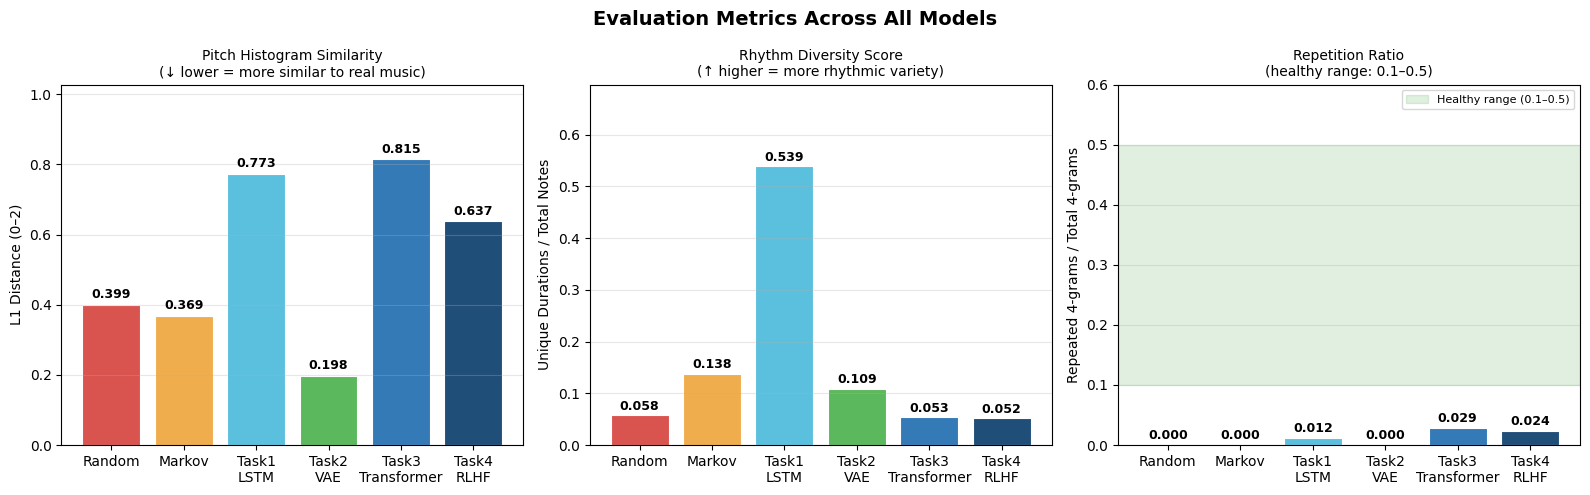

Plot saved to: /content/drive/MyDrive/MusicGenerationCSE425/outputs/plots/evaluation_metrics_comparison.png


In [ ]:
#CELL 6: Plot bar charts for all 3 metrics
#Required for report figures

models = [r['Model'] for r in summary]
phs = [r['Pitch Histogram Similarity'] for r in summary]
rds = [r['Rhythm Diversity'] for r in summary]
rep = [r['Repetition Ratio'] for r in summary]

# Short labels for x-axis
short_labels = ['Random', 'Markov', 'Task1\nLSTM', 'Task2\nVAE', 'Task3\nTransformer', 'Task4\nRLHF']

colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c', '#337ab7', '#1F4E79']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Evaluation Metrics Across All Models', fontsize=14, fontweight='bold')

# Plot 1: Pitch Histogram Similarity (lower is better)
ax = axes[0]
bars = ax.bar(short_labels, phs, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Pitch Histogram Similarity\n(↓ lower = more similar to real music)', fontsize=10)
ax.set_ylabel('L1 Distance (0–2)')
ax.set_ylim(0, max(phs) * 1.2 + 0.05)
for bar, val in zip(bars, phs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

#Plot 2: Rhythm Diversity Score (higher is better)
ax = axes[1]
bars = ax.bar(short_labels, rds, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Rhythm Diversity Score\n(↑ higher = more rhythmic variety)', fontsize=10)
ax.set_ylabel('Unique Durations / Total Notes')
ax.set_ylim(0, min(max(rds) * 1.2 + 0.05, 1.0))
for bar, val in zip(bars, rds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

#Plot 3: Repetition Ratio (0.1–0.5 is healthy)
ax = axes[2]
bars = ax.bar(short_labels, rep, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Repetition Ratio\n(healthy range: 0.1–0.5)', fontsize=10)
ax.set_ylabel('Repeated 4-grams / Total 4-grams')
ax.set_ylim(0, max(max(rep) * 1.2 + 0.05, 0.6))
#Draw healthy range band
ax.axhspan(0.1, 0.5, alpha=0.12, color='green', label='Healthy range (0.1–0.5)')
ax.legend(fontsize=8)
for bar, val in zip(bars, rep):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plot_path = f"{PLOTS_DIR}/evaluation_metrics_comparison.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {plot_path}")

In [ ]:
# CELL 7: Verify all generated MIDI files meet minimum quality
print("Verifying generated MIDI files...\n")
print(f"{'File':<45} {'Notes':>7} {'Duration':>10} {'Status':>10}")
print("-" * 78)
passed = 0
failed = 0
failed_files = []

for midi_path in sorted(glob.glob(f"{MIDI_OUT_DIR}/*.mid")):
    fname = os.path.basename(midi_path)
    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
        n_notes = sum(len(inst.notes) for inst in midi.instruments)
        duration = midi.get_end_time()

        ok = n_notes >= 50 and duration >= 5.0
        status = "PASS" if ok else "FAIL"

        if ok:
            passed += 1
        else:
            failed += 1
            failed_files.append(fname)

        print(f"{fname:<45} {n_notes:>7} {duration:>9.1f}s {status:>10}")

    except Exception as e:
        failed += 1
        failed_files.append(fname)
        print(f"{fname:<45} {'ERROR':>7} {'—':>10} {'FAIL':>10}")

print("-" * 78)
print(f"\nPassed: {passed}")
print(f"Failed: {failed}")

if failed_files:
    print(f"\nFailed files (regenerate these):")
    for f in failed_files:
        print(f"  {f}")
else:
    print("\nAll files passed verification!")

Verifying generated MIDI files...

File                                            Notes   Duration     Status
------------------------------------------------------------------------------
baseline_markov_1.mid                             100      24.4s       PASS
baseline_markov_2.mid                             100      20.1s       PASS
baseline_markov_3.mid                             100      29.2s       PASS
baseline_markov_4.mid                             100      21.9s       PASS
baseline_markov_5.mid                             100      18.1s       PASS
baseline_random_1.mid                              49      30.5s       FAIL
baseline_random_2.mid                              46      30.5s       FAIL
baseline_random_3.mid                              54      30.2s       PASS
baseline_random_4.mid                              58      30.2s       PASS
baseline_random_5.mid                              54      30.2s       PASS
rlhf_survey_sample_1.mid                          

In [ ]:
#CELL 8: Human survey scores in the summary table

human_scores = {
    'Random Generator': 2.09,
    'Markov Chain': 2.09,
    'Task 1: LSTM AE': 3.55,
    'Task 2: VAE': 1.73,
    'Task 3: Transformer': 3.36,
    'Task 4: RLHF': 3.73,
}

# Add human scores to summary table
for row in summary:
    row['Human Score (1–5)'] = human_scores.get(row['Model'], 0.0)

# Print final complete table
print("FINAL COMPLETE RESULTS TABLE")
print("=" * 100)
print(f"{'Model':<25} {'PHS (↓)':>10} {'RDS (↑)':>10} {'REP':>10} {'Human Score':>14} {'# Files':>8}")
print("-" * 100)
for row in summary:
    print(f"{row['Model']:<25} "
          f"{row['Pitch Histogram Similarity']:>10.4f} "
          f"{row['Rhythm Diversity']:>10.4f} "
          f"{row['Repetition Ratio']:>10.4f} "
          f"{row['Human Score (1–5)']:>14.2f} "
          f"{row['N Files']:>8}")
print("=" * 100)

#Save final table with human scores
final_df = pd.DataFrame(summary)
final_path = f"{PROJECT_DIR}/outputs/FINAL_results_table.csv"
final_df.to_csv(final_path, index=False)
print(f"\nFinal table saved to: {final_path}")

FINAL COMPLETE RESULTS TABLE
Model                        PHS (↓)    RDS (↑)        REP    Human Score  # Files
----------------------------------------------------------------------------------------------------
Random Generator              0.3992     0.0579     0.0000           2.09        5
Markov Chain                  0.3688     0.1380     0.0000           2.09        5
Task 1: LSTM AE               0.7727     0.5391     0.0120           3.55        5
Task 2: VAE                   0.1979     0.1086     0.0000           1.73        8
Task 3: Transformer           0.8146     0.0535     0.0289           3.36       10
Task 4: RLHF                  0.6372     0.0519     0.0242           3.73       10

Final table saved to: /content/drive/MyDrive/MusicGenerationCSE425/outputs/FINAL_results_table.csv
